# 04 · Modelo — Gradient Boosting
### Entrenamiento · Optimización · Evaluación · Persistencia
---


In [1]:
import sys, os
_here = os.getcwd()
ROOT  = _here
for _ in range(5):
    if os.path.isdir(os.path.join(ROOT, 'src')):
        break
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     StratifiedKFold, learning_curve)
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, recall_score, precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)

from src.data_loader import DataLoader
from src.preprocessing import ProcesadorDatos

TRAINED_DIR = os.path.join(ROOT, 'models', 'trained')
FIGURES_DIR = os.path.join(ROOT, 'reports', 'figures')
os.makedirs(TRAINED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

def guardar(nombre):
    plt.savefig(os.path.join(FIGURES_DIR, nombre), dpi=110, bbox_inches='tight')

loader     = DataLoader(os.path.join(ROOT, 'data', 'indian_roads_dataset.csv'))
df         = loader.cargar_datos()
procesador = ProcesadorDatos()
X, y       = procesador.preparar_datos(df)

SEED = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

display(pd.DataFrame({'Conjunto':['Train','Test'],
                      'Registros':[len(X_train),len(X_test)],
                      '%':['80%','20%']})
        .style.set_caption('División train/test').hide(axis='index'))


Conjunto,Registros,%
Train,16000,80%
Test,4000,20%


## 4.1 Hiperparámetros 
buscados con GridSearchCV

In [2]:
params = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.8, 1.0],
    'min_samples_leaf': [1, 5],
}

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

gs = GridSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    params, cv=CV, scoring='f1_weighted', n_jobs=-1, verbose=1
)
gs.fit(X_train, y_train)

display(pd.DataFrame(list(gs.best_params_.items()),
                     columns=['Hiperparámetro','Valor óptimo'])
        .style.set_caption(f'Mejores hiperparámetros — CV F1 train: {gs.best_score_:.4f}')
        .hide(axis='index'))


Fitting 5 folds for each of 72 candidates, totalling 360 fits


Hiperparámetro,Valor óptimo
learning_rate,0.200000
max_depth,7.000000
min_samples_leaf,1.000000
n_estimators,200.000000
subsample,0.800000


La tabla presentada muestra la mejor combinación de hiperparámetros encontrados, obteniendo un F1-score promedio de 0.6214 en entrenamiento. 

## 4.2 Evaluación en test

In [3]:
gb     = gs.best_estimator_
y_pred = gb.predict(X_test)

display(pd.DataFrame([{
    'Accuracy'          : round(accuracy_score(y_test, y_pred), 4),
    'F1 ponderado'      : round(f1_score(y_test, y_pred, average='weighted'), 4),
    'Recall ponderado'  : round(recall_score(y_test, y_pred, average='weighted'), 4),
    'Precision ponderada': round(precision_score(y_test, y_pred, average='weighted'), 4),
}]).style.set_caption('Métricas de evaluación — Gradient Boosting').hide(axis='index'))

display(pd.DataFrame(classification_report(y_test, y_pred, output_dict=True))
        .T.round(4).style.set_caption('Reporte de clasificación completo'))


Accuracy,F1 ponderado,Recall ponderado,Precision ponderada
0.626800,0.612100,0.626800,0.604000


,precision,recall,f1-score,support
fatal,0.996700,1.000000,0.998300,597.000000
major,0.337000,0.253800,0.289500,1198.000000
minor,0.642700,0.728300,0.682800,2205.000000
accuracy,0.626800,0.626800,0.626800,0.626800
macro avg,0.658800,0.660700,0.656900,4000.000000
weighted avg,0.604000,0.626800,0.612100,4000.000000


El análisis por clase permitió identificar que el modelo tiene un comportamiento desigual entre categorías, siendo más efectivo en algunas clases que en otras. Esto evidencia posibles dificultades para identificar correctamente ciertos niveles de severidad como en la clase "major" donde se envidencia la peor clasificación. 

## 4.3 Matriz de confusión

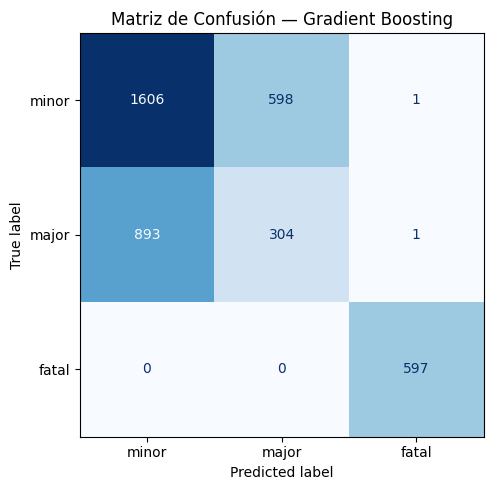

In [4]:
cm = confusion_matrix(y_test, y_pred, labels=['minor','major','fatal'])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['minor','major','fatal']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Matriz de Confusión — Gradient Boosting')
plt.tight_layout()
guardar('cm_gradient_boosting.png')
plt.show()


## 4.4 Importancia de features

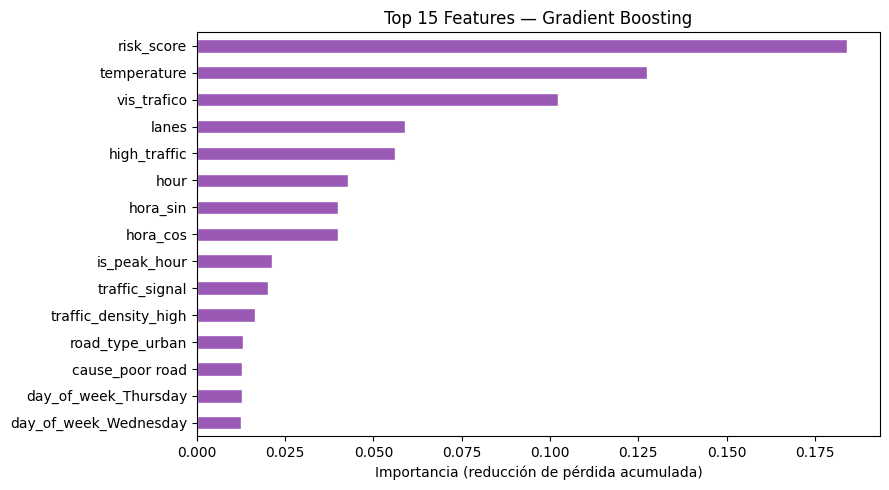

Feature,Importancia
risk_score,0.184300
temperature,0.127400
vis_trafico,0.102300
lanes,0.058800
high_traffic,0.056000
hour,0.042800
hora_sin,0.040000
hora_cos,0.039900
is_peak_hour,0.021400
traffic_signal,0.020100


In [5]:
imp = (pd.Series(gb.feature_importances_, index=X_train.columns)
         .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 5))
imp[::-1].plot(kind='barh', ax=ax, color='#9B59B6', edgecolor='white')
ax.set_title('Top 15 Features — Gradient Boosting')
ax.set_xlabel('Importancia (reducción de pérdida acumulada)')
plt.tight_layout()
guardar('feat_imp_gb.png')
plt.show()

display(imp.round(4).reset_index()
        .rename(columns={'index':'Feature', 0:'Importancia'})
        .style.set_caption('Top 15 features — Gradient Boosting').hide(axis='index'))


## 4.5 Curva de aprendizaje

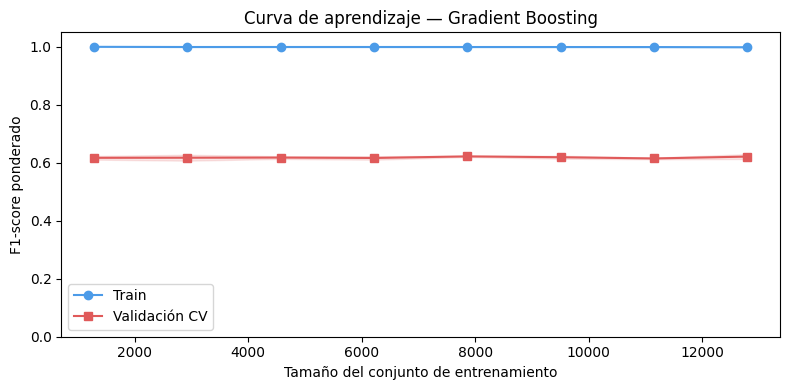

In [6]:
tr_sz, tr_sc, val_sc = learning_curve(
    gb, X_train, y_train,
    cv=CV, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 8), n_jobs=-1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tr_sz, tr_sc.mean(axis=1),  'o-', color='#4C9BE8', label='Train')
ax.plot(tr_sz, val_sc.mean(axis=1), 's-', color='#E05A5A', label='Validación CV')
ax.fill_between(tr_sz,
    tr_sc.mean(axis=1) - tr_sc.std(axis=1),
    tr_sc.mean(axis=1) + tr_sc.std(axis=1), alpha=0.15, color='#4C9BE8')
ax.fill_between(tr_sz,
    val_sc.mean(axis=1) - val_sc.std(axis=1),
    val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.15, color='#E05A5A')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('F1-score ponderado')
ax.set_title('Curva de aprendizaje — Gradient Boosting')
ax.legend(); ax.set_ylim(0, 1.05)
plt.tight_layout()
guardar('lc_gradient_boosting.png')
plt.show()


## 4.6 Guardar modelo en `models/trained/`

In [7]:
ruta_pkl = os.path.join(TRAINED_DIR, 'gradient_boosting.pkl')
joblib.dump(gb, ruta_pkl)

display(pd.DataFrame([{
    'Archivo': ruta_pkl,
    'Tamaño KB': round(os.path.getsize(ruta_pkl)/1024, 1),
    'Estado': 'Guardado ✅'
}]).style.set_caption('Modelo persistido en models/trained/').hide(axis='index'))


Archivo,Tamaño KB,Estado
c:\Users\PC\Downloads\Proyecto_ML\models\trained\gradient_boosting.pkl,8921.700000,Guardado ✅
